# Section 1
Edge Detection

In [1]:
!gdown "1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc"

Downloading...
From: https://drive.google.com/uc?id=1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc
To: /content/lab 06 noisy_image.jpg
100% 107k/107k [00:00<00:00, 56.6MB/s]


Given an image with noise, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm is most sensitive to noise?

- Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?

- Q3. Which algorithm do you think is best for processing high noise images?  Justify your answer.




In [45]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


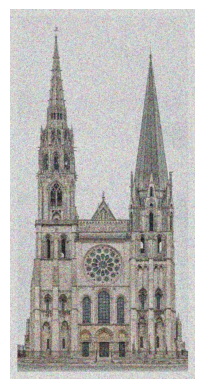

In [46]:
img= cv.imread('/content/lab 06 noisy_image.jpg')
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

##1.Sobel operator

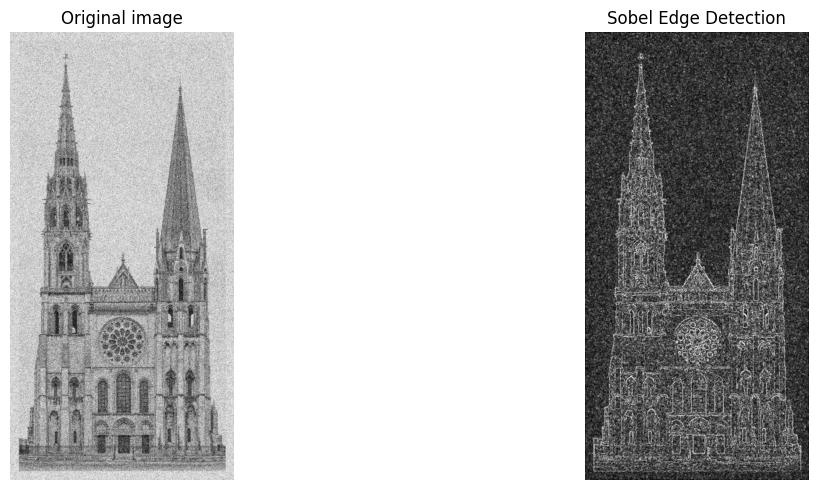

In [8]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 noisy_image.jpg', 0)

# Step 2: Compute Sobel gradient results
x = cv.Sobel(img, cv.CV_16S, 1, 0)  # Horizontal gradient (dx=1, dy=0)
y = cv.Sobel(img, cv.CV_16S, 0, 1)  # Vertical gradient (dx=0, dy=1)

# Step 3: Convert data to uint8 format
Scale_absX = cv.convertScaleAbs(x)
Scale_absY = cv.convertScaleAbs(y)

# Step 4: Combine results
result = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)
# result=(255×0.5)+(255×0.5) =127.5+127.5=255

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Original image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sobel Edge Detection")
plt.imshow(result, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##2.Canny algorithm

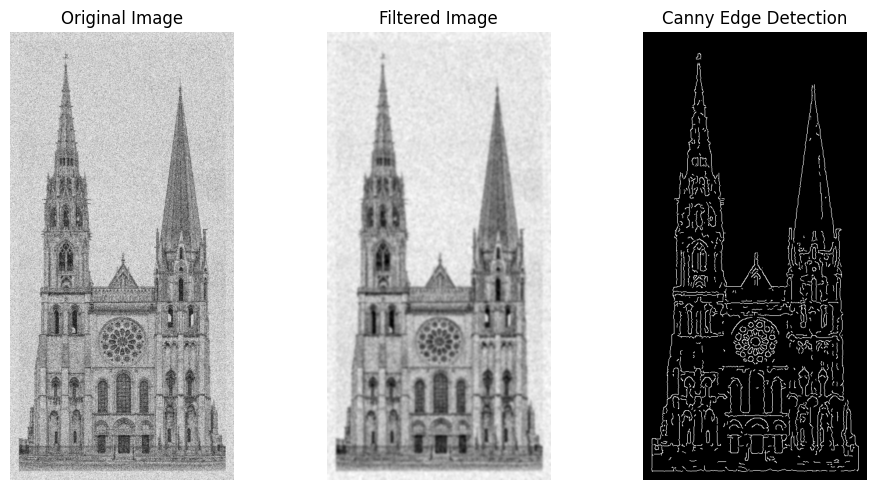

In [43]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 noisy_image.jpg', 0)

# Step 2: Perform Canny edge detection
lowThreshold = 70 # Set the lower threshold for edge detection
highThreshold = 90  # Set the upper threshold for edge detection

# Apply Canny edge detection
filtered_img = cv.GaussianBlur(img, (9, 9), 0)
canny_result = cv.Canny(filtered_img, lowThreshold, highThreshold)
#  Default is 3x3 and Sobel is used for gradient computation

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Filtered Image")
plt.imshow(filtered_img, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_result, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##3.Mar-hildreth algorithm

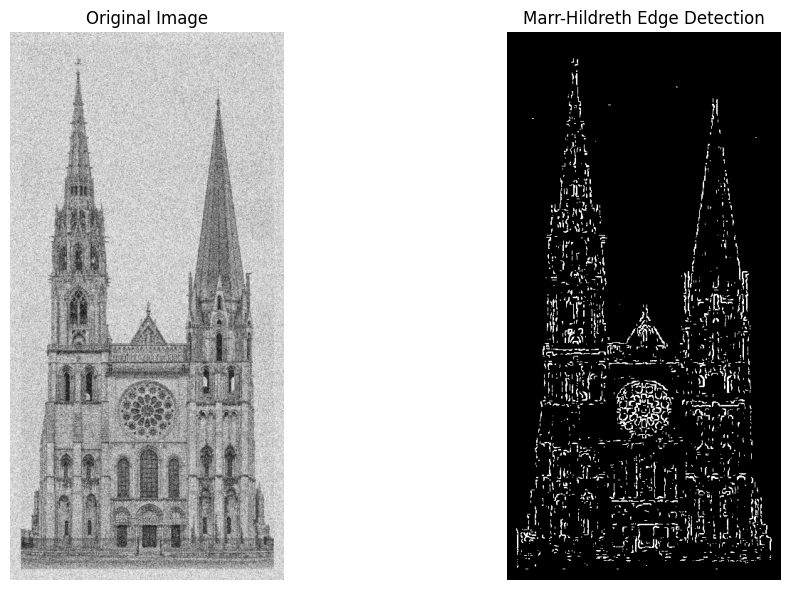

In [88]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 noisy_image.jpg', 0)  # Load image in grayscale

# Step 2: Apply Gaussian filter (smoothing)
blurred = cv.GaussianBlur(img, (11, 11), 0)

# Step 3: Compute Laplacian of the smoothed image
laplacian = cv.Laplacian(blurred, cv.CV_64F)  # Use CV_64F to capture negative values

# Step 4: Detect Zero-Crossings with Thresholding
threshold = 4  # Set a threshold for significant edges
# A threshold is used to ignore small variations (caused by noise or minor gradients) and focus only on significant changes in the Laplacian values

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)
# A new matrix is created with the same shape as the laplacian result, initialized with zeros. This matrix will store the edges

rows, cols = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 4×4 Neighborhood
        patch = laplacian[i-1:i+3, j-1:j+3]  # 4x4 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

# Display the original image and Marr-Hildreth result
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

# Marr-Hildreth Edge Detection
plt.subplot(1, 2, 2)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##Explaination answer

Q1. Which algorithm is most sensitive to noise?<br>
A1: Sobel operator because sobel don't have solution to reduct noise that mean sobel think a lof of noise is an edge.
<br><br>
Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?<br>
A2: Because we do Gaussian blur for reduct noise. When i adjust kernal size or standard deviation that mean how smoot of noise can reducrt if thne noise gone a lot edge can detect easily but if we smoot too much(large kernal size or high SD) the edge it smoot also then it hard to detect edge.
<br><br>
Q3. Which algorithm do you think is best for processing high noise images? Justify your answer.<br>
A3: In this case (lab 06 noisy_image.jpg) i like Canny bacause it need adjust little parameters then the result look good more than others.

# Section 2


In [92]:
!gdown "1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd"

Downloading...
From: https://drive.google.com/uc?id=1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd
To: /content/lab 06 church.jpg
100% 209k/209k [00:00<00:00, 5.82MB/s]


Given an image, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm produces the most detailed edges?
- Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.
- Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?




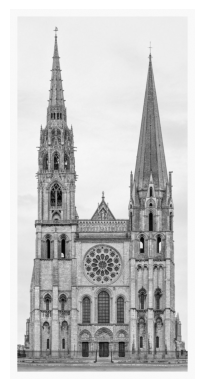

In [95]:
img= cv.imread('/content/lab 06 church.jpg', 0)
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.show()

##1.Sobel operator

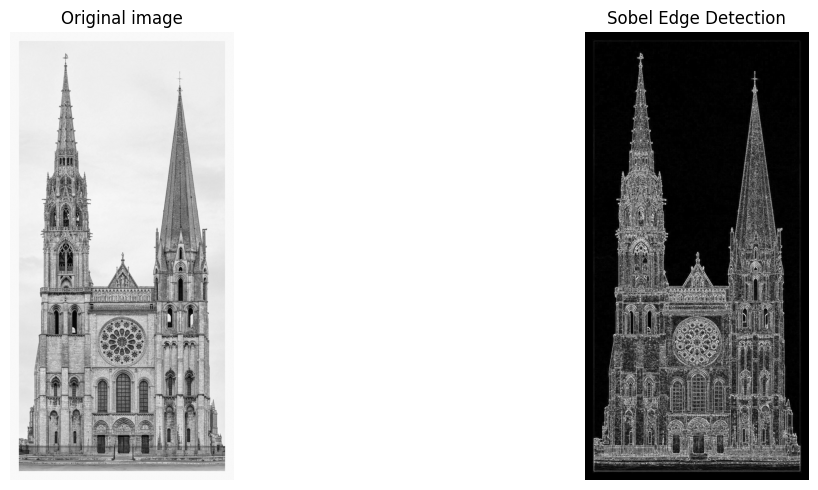

In [96]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 church.jpg', 0)

# Step 2: Compute Sobel gradient results
x = cv.Sobel(img, cv.CV_16S, 1, 0)  # Horizontal gradient (dx=1, dy=0)
y = cv.Sobel(img, cv.CV_16S, 0, 1)  # Vertical gradient (dx=0, dy=1)

# Step 3: Convert data to uint8 format
Scale_absX = cv.convertScaleAbs(x)
Scale_absY = cv.convertScaleAbs(y)

# Step 4: Combine results
result = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)
# result=(255×0.5)+(255×0.5) =127.5+127.5=255

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Original image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sobel Edge Detection")
plt.imshow(result, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##2.Canny algorithm

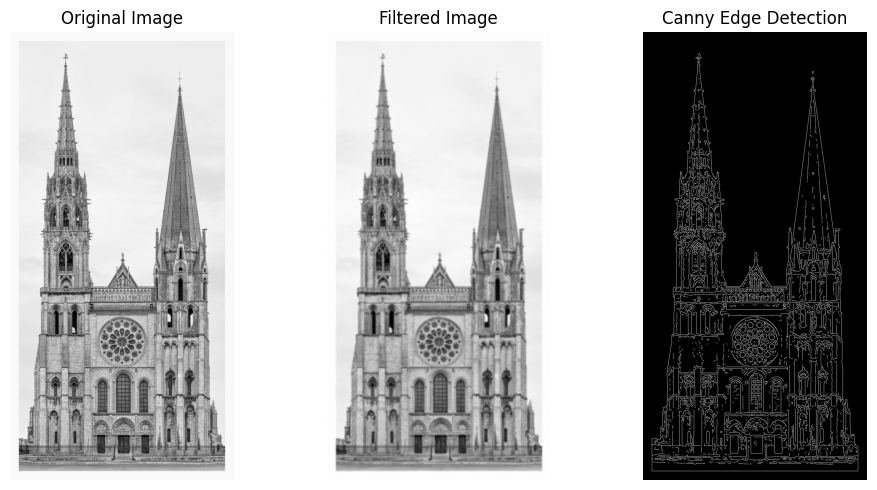

In [99]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 church.jpg', 0)

# Step 2: Perform Canny edge detection
lowThreshold = 70 # Set the lower threshold for edge detection
highThreshold = 90  # Set the upper threshold for edge detection

# Apply Canny edge detection
filtered_img = cv.GaussianBlur(img, (9, 9), 0)
canny_result = cv.Canny(filtered_img, lowThreshold, highThreshold)
#  Default is 3x3 and Sobel is used for gradient computation

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Filtered Image")
plt.imshow(filtered_img, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_result, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##3.Mar-hildreth algorithm

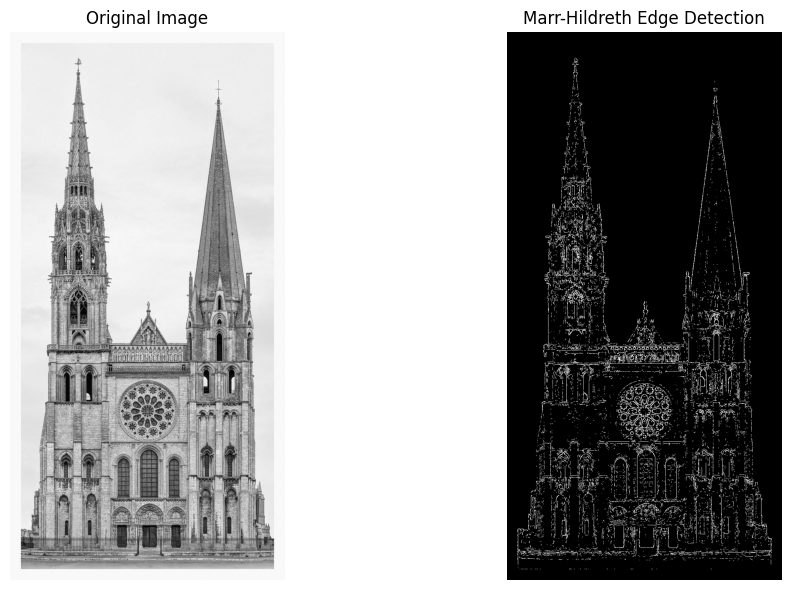

In [106]:
# Step 1: Read the image
img = cv.imread('/content/lab 06 church.jpg', 0)  # Load image in grayscale

# Step 2: Apply Gaussian filter (smoothing)
blurred = cv.GaussianBlur(img, (9, 9), 0)

# Step 3: Compute Laplacian of the smoothed image
laplacian = cv.Laplacian(blurred, cv.CV_64F)  # Use CV_64F to capture negative values

# Step 4: Detect Zero-Crossings with Thresholding
threshold = 5.5  # Set a threshold for significant edges
# A threshold is used to ignore small variations (caused by noise or minor gradients) and focus only on significant changes in the Laplacian values

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)
# A new matrix is created with the same shape as the laplacian result, initialized with zeros. This matrix will store the edges

rows, cols = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3*3 Neighborhood
        patch = laplacian[i-1:i+2, j-1:j+2]  # 3*3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

# Display the original image and Marr-Hildreth result
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

# Marr-Hildreth Edge Detection
plt.subplot(1, 2, 2)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


##Explaination answer

Q1. Which algorithm produces the most detailed edges?<br>
A1: For me eyes it's Canny.
<br><br>
Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.<br>
A2: base on my eyes it's Canny compare with Sobel it have perfect edge but have a lot of noise on the edge but canny show only sharp edge and the noise in object is reduct by Gaussian.   
<br>
Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?<br>
A3: For me it's Canny.

# Section 3

**Lane Detection**

Lane detection is one of the basic concepts when trying to understand how self-driving cars work.Hough transform can help to detect straight lines in the region of interest.

**Q1 : In this section you will deal with 2 image of lane data and try to show result of lane detection.**

**Tools**
* Edge Detection Ex. Canny.
* Line Detection Ex. Hough Transform Technique.
* Other tools you can also use to apply in your code.

> This is 2 image data for using in your code of this section.



In [107]:
# Road1 gray-scale image (name:lane.jpg)
!gdown "1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ"

Downloading...
From: https://drive.google.com/uc?id=1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ
To: /content/lane.jpg
100% 35.2k/35.2k [00:00<00:00, 31.2MB/s]


In [108]:
# Road2 color image (name:lane2.jpg)
!gdown "1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF"

Downloading...
From: https://drive.google.com/uc?id=1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF
To: /content/lane2.jpg
100% 776k/776k [00:00<00:00, 7.78MB/s]


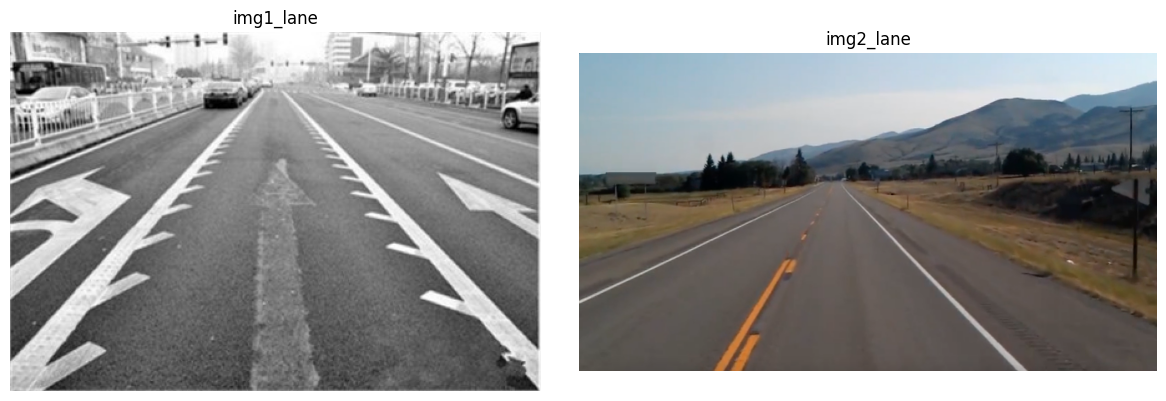

In [109]:
img1_lane= cv.imread('/content/lane.jpg')
img2_lane= cv.imread('/content/lane2.jpg')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img1_lane')
plt.axis('off')

# Step 9: results of dest diliated
plt.subplot(1, 2, 2)
plt.imshow(img2_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img2_lane')
plt.axis('off')

plt.tight_layout()
plt.show()


##Gray-scale image

In [110]:
import cv2

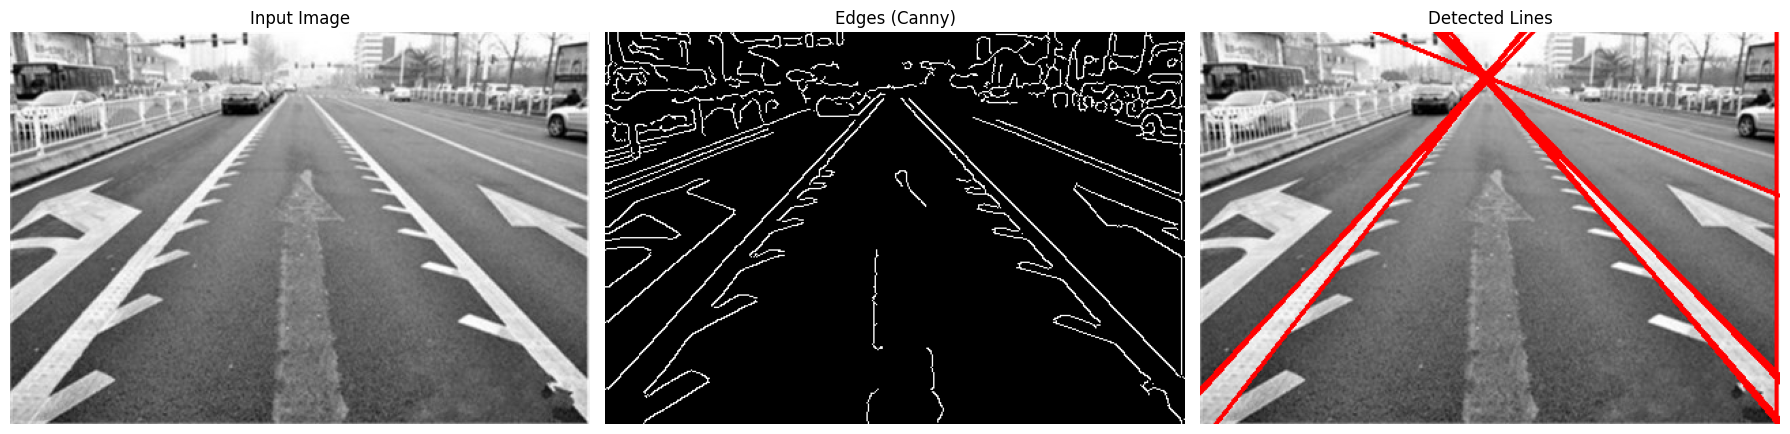

In [119]:
#Add your code here!
# Load the image
image = cv2.imread('lane.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Preprocessing (Edge Detection)
filtered_img = cv.GaussianBlur(image, (9, 9), 1.9)
edges = cv2.Canny(filtered_img, threshold1=50, threshold2=100, apertureSize=3)

# Step 2: Hough Transform for Line Detection
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=120)

# Step 3: Draw the detected lines on the original image
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert grayscale to BGR

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(output_image, (x1, y1), (x2, y2), (0, 0, 255), 2)


# Step 4: Visualization
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edges (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Detected Lines")
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


##Color image

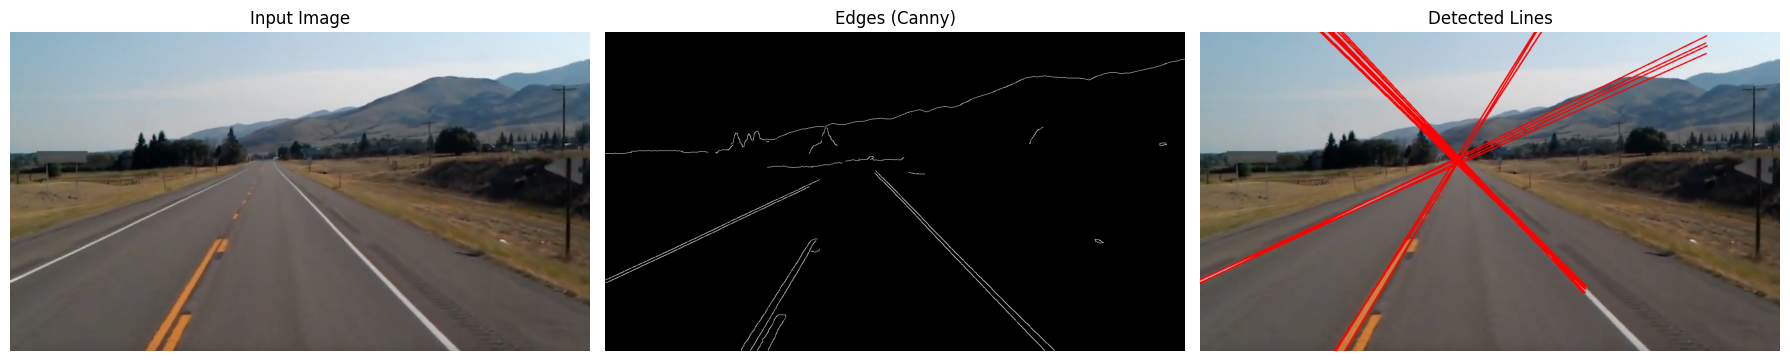

In [136]:
#Add your code here!
# Load the image
image = cv2.imread('lane2.jpg')

# Step 1: Preprocessing (Edge Detection)
filtered_img = cv.GaussianBlur(image, (11, 11), 0)
edges = cv2.Canny(filtered_img, threshold1=50, threshold2=130, apertureSize=3)

# Step 2: Hough Transform for Line Detection
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=120)

# Step 3: Draw the detected lines on the original image
output_image = image.copy()  # Convert grayscale to BGR

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(output_image, (x1, y1), (x2, y2), (0, 0, 255), 2)


# Step 4: Visualization
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edges (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Detected Lines")
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


##Q2

**Q2 : How are these two images from the lane dataset obstacles for you when implementing the code to detect lane results?**

***(Explaination answer)***

Ans. for me it's about how clear of the line are bacause when road have a bit of noise of light not enough that effect a lot with edge detection algorithm then it hard to detect the line